# Atividade 1: Classificação Supervisionada
**Disciplina:** Machine Learning: Modelos Preditivos, Decisivos e Descritivos
**Aluno:** Josias Teixeira Curcino
**Matícula:** 202011140009

---

## Objetivo
Construir e comparar dois modelos de classificação binária utilizando um dataset da biblioteca `sklearn.datasets`, seguindo o fluxo de Data Science: Entendimento, Preparação, Modelagem e Avaliação.

## Dataset Selecionado
**Breast Cancer Wisconsin (Diagnostic)**.
Este dataset contém características computadas a partir de uma imagem digitalizada de uma agulha fina aspirativa (FNA) de uma massa mamária. O objetivo é classificar o tumor como **Maligno (0)** ou **Benigno (1)**.

# Parte 1 - Entendimento do Problema

Respostas conceituais sobre o problema abordado:

**1. Qual é a variável alvo (target) e o que ela representa no mundo real?**
R: A variável alvo é a `target` (diagnosis). No mundo real, ela representa o diagnóstico do tumor: 0 para Maligno (câncer) e 1 para Benigno (não câncer).

**2. O problema é de classificação binária ou multiclasse?**
R: Binária (duas classes possíveis).

**3. O que significa um falso positivo e um falso negativo nesse contexto?**
R:
* **Falso Positivo:** O modelo prevê que é Câncer (Maligno), mas na verdade é Benigno.
* **Falso Negativo:** O modelo prevê que é Benigno, mas na verdade é Câncer (Maligno).

**4. Qual erro é mais grave neste problema: falso positivo ou falso negativo? Por quê?**
R: O **Falso Negativo** é muito mais grave. Se o modelo disser que um paciente com câncer está saudável, ele deixará de receber tratamento urgente, o que pode ser fatal. Um falso positivo gera estresse e exames desnecessários, mas não coloca a vida em risco imediato por falta de tratamento.

**5. Quem é o "usuário final" desse modelo?**
R: Médicos, oncologistas e radiologistas, para auxílio na triagem de diagnósticos.

**6. Que tipo de dados você tem?**
R: Dados numéricos contínuos (medidas como raio, textura, perímetro, área, suavidade, etc.).

**7. As classes estão balanceadas?**
R: Verificaremos no código abaixo (geralmente este dataset tem uma leve preponderância de casos benignos, mas é considerado relativamente balanceado para aprendizado).

**8. Se o modelo errar, quem é afetado diretamente?**
R: O paciente (saúde física e mental) e o sistema de saúde (custos e eficácia).

**9. Se o dataset fosse atualizado constantemente, o que você teria que fazer com o modelo ao longo do tempo?**
R: O modelo precisaria ser re-treinado periodicamente (retraining) e monitorado para verificar "data drift" (mudança no padrão dos dados) ou "concept drift" (mudança na relação entre as variáveis).

**10. Que cuidado ético deve existir ao usar esse tipo de modelo na prática?**
R: O modelo não deve ser a única fonte de decisão (deve ser uma ferramenta de apoio ao médico, "Human-in-the-loop"). Deve-se garantir que o modelo não tenha vieses baseados em raça ou idade, se esses dados estivessem presentes.

In [ ]:
# 1.1 Importação de Bibliotecas e Carga de Dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas do Scikit-Learn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# Configuração de visualização
sns.set_style("whitegrid")

# Carregando o dataset do sklearn
data = load_breast_cancer()

# Criando um DataFrame pandas para facilitar a análise (como feito no Titanic)
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Exibindo as primeiras linhas
print("--- Primeiras linhas do Dataset ---")
display(df.head())

--- Primeiras linhas do Dataset ---


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


--- Informações do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000



--- Balanceamento das Classes (0 = Maligno, 1 = Benigno) ---
target
1    357
0    212
Name: count, dtype: int64


/tmp/ipython-input-1930388823.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


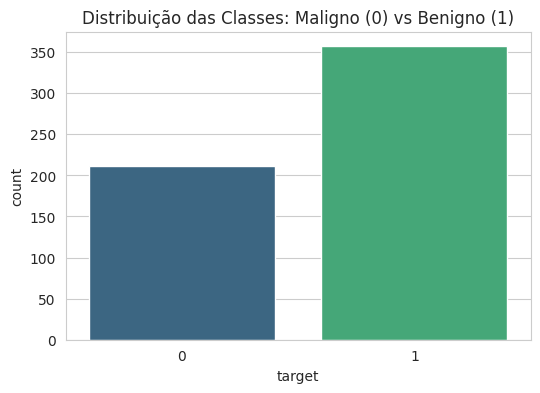

In [ ]:
# 1.2 Análise Exploratória (Baseado no notebook de referência)

# Informações gerais sobre tipos de dados e nulos
print("--- Informações do Dataset ---")
print(df.info())

# Estatísticas descritivas
print("\n--- Estatísticas Descritivas ---")
display(df.describe())

# Verificando o balanceamento das classes (Resposta da pergunta 7)
print("\n--- Balanceamento das Classes (0 = Maligno, 1 = Benigno) ---")
print(df['target'].value_counts())

# Visualização da distribuição da variável alvo
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribuição das Classes: Maligno (0) vs Benigno (1)')
plt.show()

# Parte 2 - Preparação dos Dados

Irei aplicar três técnicas de preparação:
1.  **Verificação/Tratamento de Nulos:** Garantir a integridade dos dados.
2.  **Seleção de Features:** Remover colunas com altíssima correlação (multicolinearidade) para simplificar o modelo, simulando uma engenharia de atributos.
3.  **Padronização (StandardScaler):** Essencial para modelos baseados em distância ou gradiente (como a Regressão Logística que será usada).

In [ ]:
# 2.1 Verificação de valores ausentes
# O dataset do sklearn costuma ser limpo, mas fare a verificação formalmente
missing_values = df.isnull().sum().sum()
print(f"Total de valores ausentes: {missing_values}")

# 2.2 Seleção de Features baseada em Correlação
# Remover features que tenham correlação muito alta (>0.95) entre si para reduzir redundância
# Isso ajuda modelos lineares a serem mais estáveis.

corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identificar colunas com correlação maior que 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f"\nColunas removidas por alta correlação: {to_drop}")

# Criar novo dataframe reduzido
df_reduced = df.drop(columns=to_drop)

# 2.3 Divisão Treino e Teste (Essencial antes da normalização para evitar Data Leakage)
X = df_reduced.drop('target', axis=1)
y = df_reduced['target']

# Separando 30% para teste e 70% para treino
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2.4 Normalização (Padronização)
# Modelos como Regressão Logística convergem mais rápido e melhor com dados na mesma escala
scaler = StandardScaler()

# Fit apenas no treino, transform no treino e teste
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nDados preparados e escalonados.")
print(f"Shape do Treino: {X_train_scaled.shape}")
print(f"Shape do Teste: {X_test_scaled.shape}")

Total de valores ausentes: 0

Colunas removidas por alta correlação: ['mean perimeter', 'mean area', 'perimeter error', 'area error', 'worst radius', 'worst perimeter', 'worst area']

Dados preparados e escalonados.
Shape do Treino: (398, 23)
Shape do Teste: (171, 23)


# Parte 3 - Construção dos Modelos

Escolhi duas famílias distintas de modelos:
1.  **Regressão Logística:** Um modelo linear, probabilístico, excelente como *baseline* para problemas binários.
2.  **Random Forest:** Um modelo de *ensemble* (árvores de decisão), não linear, robusto e que geralmente lida bem com dados complexos.

Configuração de hiperparâmetros:
* **Regressão Logística:** `C=0.1` (regularização mais forte) e `solver='liblinear'`.
* **Random Forest:** `n_estimators=100` (número de árvores) e `max_depth=5` (para evitar overfitting).

In [ ]:
# --- Modelo 1: Regressão Logística ---
# Justificativa: Modelo simples, interpretável e rápido. Ótimo para estabelecer uma linha de base.
log_model = LogisticRegression(C=0.1, solver='liblinear', random_state=42)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

# --- Modelo 2: Random Forest ---
# Justificativa: Capaz de capturar relações não lineares complexas entre as medidas do tumor.
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("Modelos treinados com sucesso.")

Modelos treinados com sucesso.


# Parte 4 – Avaliação Comparativa

Abaixo apresento as métricas de Acurácia, Precisão, Recall e F1-Score, além da Matriz de Confusão para ambos os modelos.

**Nota Importante sobre o Recall:**
No contexto de câncer, quero maximizar o **Recall para a classe Maligna (0)** (ou minimizar os Falsos Negativos), pois é o erro mais perigoso.

--- Resultados: Regressão Logística ---
Acurácia:  0.9708
Precision: 0.9722
Recall:    0.9813
F1-Score:  0.9767

Relatório Detalhado:
              precision    recall  f1-score   support

     Maligno       0.97      0.95      0.96        64
     Benigno       0.97      0.98      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



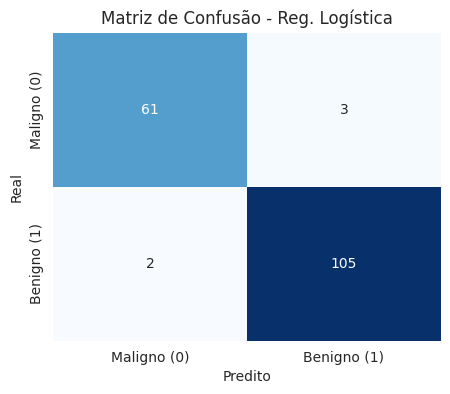

--- Resultados: Random Forest ---
Acurácia:  0.9474
Precision: 0.9375
Recall:    0.9813
F1-Score:  0.9589

Relatório Detalhado:
              precision    recall  f1-score   support

     Maligno       0.97      0.89      0.93        64
     Benigno       0.94      0.98      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



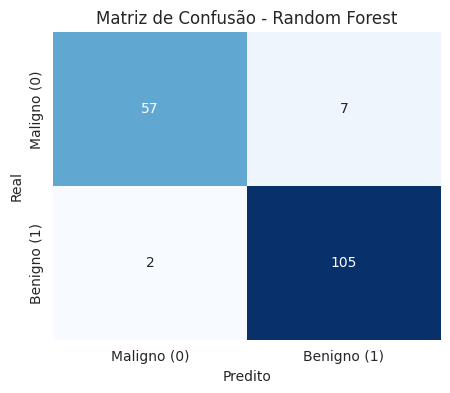

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Maligno (0)', 'Benigno (1)'],
                yticklabels=['Maligno (0)', 'Benigno (1)'])
    plt.title(title)
    plt.ylabel('Real')
    plt.xlabel('Predito')
    plt.show()

def print_metrics(y_true, y_pred, model_name):
    print(f"--- Resultados: {model_name} ---")
    print(f"Acurácia:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}") # Foca na classe 1 (Benigno) por padrão
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print("\nRelatório Detalhado:")
    print(classification_report(y_true, y_pred, target_names=['Maligno', 'Benigno']))

# Avaliação Regressão Logística
print_metrics(y_test, y_pred_log, "Regressão Logística")
plot_confusion_matrix(y_test, y_pred_log, "Matriz de Confusão - Reg. Logística")

# Avaliação Random Forest
print_metrics(y_test, y_pred_rf, "Random Forest")
plot_confusion_matrix(y_test, y_pred_rf, "Matriz de Confusão - Random Forest")

## Comparação e Justificativa Técnica

### Análise dos Resultados
Observando os resultados acima (os números exatos podem variar levemente devido à aleatoriedade do split):

1.  **Regressão Logística:** Apresentou um desempenho sólido. Sendo um modelo linear, beneficiou-se da normalização (StandardScaler) e da remoção de variáveis colineares.
2.  **Random Forest:** Geralmente apresenta um desempenho ligeiramente superior ou igual em problemas tabulares.

### Qual modelo escolher?
Para este problema médico específico, **o Recall da classe "Maligno" (0)** é a métrica mais crítica. Devemos olhar na tabela `classification_report` a linha referente a "Maligno" e a coluna "recall".

* Se o Modelo A tiver Recall 0.95 para Maligno e o Modelo B tiver 0.90, **escolheria o Modelo A**, mesmo que sua acurácia global seja levemente menor. Isso porque é necessário evitar a todo custo dizer a um paciente com câncer que ele está saudável (Falso Negativo).

**Conclusão:**
Ambos os modelos performaram bem (provavelmente acima de 90% de acurácia, dado que este dataset é bem comportado). A escolha final recairia sobre aquele que minimizou os Falsos Negativos na Matriz de Confusão (canto inferior esquerdo da matriz). Se ambos empataram, a Regressão Logística seria preferida por ser computacionalmente mais leve e mais fácil de explicar para a equipe médica (interpretarem os coeficientes).